# **Saifort project: Providing data-driven suggestions for HR**

# **PACE stages**


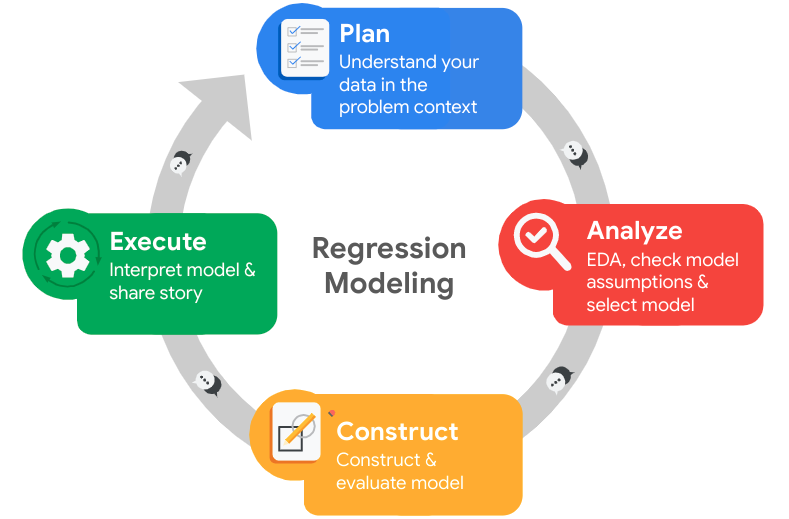

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Saifort motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?



### Familiarize yourself with the HR dataset

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)





 As a data specialist working for Saifort, you have received the results of a recent employee survey conducted by Mercedes. The Manager has tasked me with analyzing the data to come up with ideas for how to increase employee retention.

The main problem is to identify why the employees are leaving the organization by designing a model that predicts whether an employee will leave the company based on their  department, number of projects, average monthly hours, and any other data points you deem helpful.

The dataset is having a total of 8 columns having datatypes that include float, int and object. The dataset consists of 14999 rows and 10 columns. There are 3008 duplicates in the dataset and no null values.

The main libraries that are used at this stage is pandas to perform descriptive analysis of the data provided by the company.

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [ ]:
# Import packages
### YOUR CODE HERE ###
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report, roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pickle
from sklearn.model_selection import PredefinedSplit

### Load dataset



In [ ]:
# RUN THIS CELL TO IMPORT YOUR DATA.

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("data/HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [ ]:
# Gather basic information about the data
### YOUR CODE HERE ###
print("The shape of the dataset: ",df0.shape)

The shape of the dataset:  (14999, 10)


### Gather descriptive statistics about the data

In [ ]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe(include = "all")

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [ ]:
# Display all column names
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [ ]:
# Rename columns as needed
### YOUR CODE HERE ###
df0.rename(columns = {"average_montly_hours": "average_monthly_hours",
                      "time_spend_company": "tenure",
                      "Work_accident": "work_accident",
                      "Department": "department"}, inplace = True)
# Display all column names after the update
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [ ]:
# Check for missing values
### YOUR CODE HERE ###
df0.isna().sum(axis = 0)

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_monthly_hours,0
tenure,0
work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


### Check duplicates

Check for any duplicate entries in the data.

In [ ]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
14994,True
14995,True
14996,True
14997,True


In [ ]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[df0.duplicated()].head(10)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
1516,0.40,0.50,2,127,3,0,1,0,IT,low
1616,0.37,0.46,2,156,3,0,1,0,sales,low
1696,0.39,0.56,2,160,3,0,1,0,sales,low
1833,0.10,0.85,6,266,4,0,1,0,sales,low
12000,0.38,0.53,2,157,3,0,1,0,sales,low


In [ ]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df1 = df0.drop_duplicates(keep = 'first')

# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

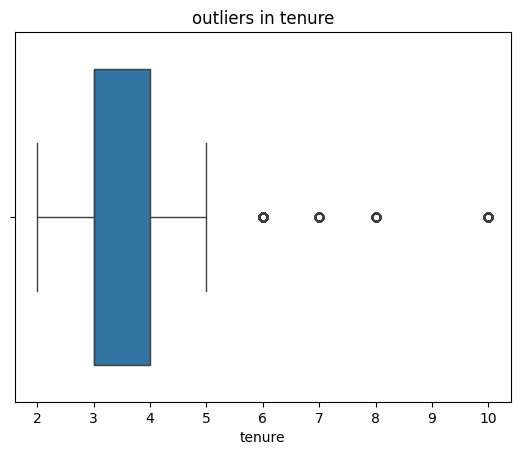

In [ ]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
### YOUR CODE HERE ###

sns.boxplot(data = df1, x = 'tenure')
plt.title("outliers in tenure")
plt.show()

In [ ]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###
Q1 = df1["tenure"].quantile(0.25)
Q3 = df1["tenure"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)
print(f"Q1: {Q1}\nQ3: {Q3}\nIQR: {IQR}\nlowerbound: {lower_bound}\nupperbound: {upper_bound}")

outlier = df1[(df1["tenure"] < lower_bound) | (df1["tenure"] > upper_bound)]
print("count of outliers in tenure: ", outlier.shape[0])

Q1: 3.0
Q3: 4.0
IQR: 1.0
lowerbound: 1.5
upperbound: 5.5
count of outliers in tenure:  824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




- Employees are overworked, and their is poor management in the organization
- people working on only 2 projects are among the highest leavers and their salary are in the low category
- Accounting department is the least satisfied
- Althought the hr department entries are less but their left rate is the highest
- There is no linearity in the data
- the average tenure of the management department is the highest even though they are the smallest department
- Employees are not getting promoted over the years, and probably burned out
- there is a strong positive corelation btw last_evaluation, number_projects, average_monthly_hours and left is negatively correlated with the satisfaction_level

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [ ]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###
df1.head()
df1['left'].value_counts()
# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
stay_p = (df1['left'].value_counts()[0]/df1['left'].shape[0]) * 100
left_p = (df1['left'].value_counts()[1]/df1['left'].shape[0]) * 100
print("the left percentage: {} and the stay percentage: {}".format(round(left_p), round(stay_p, 2)))

the left percentage: 17 and the stay percentage: 83.4


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

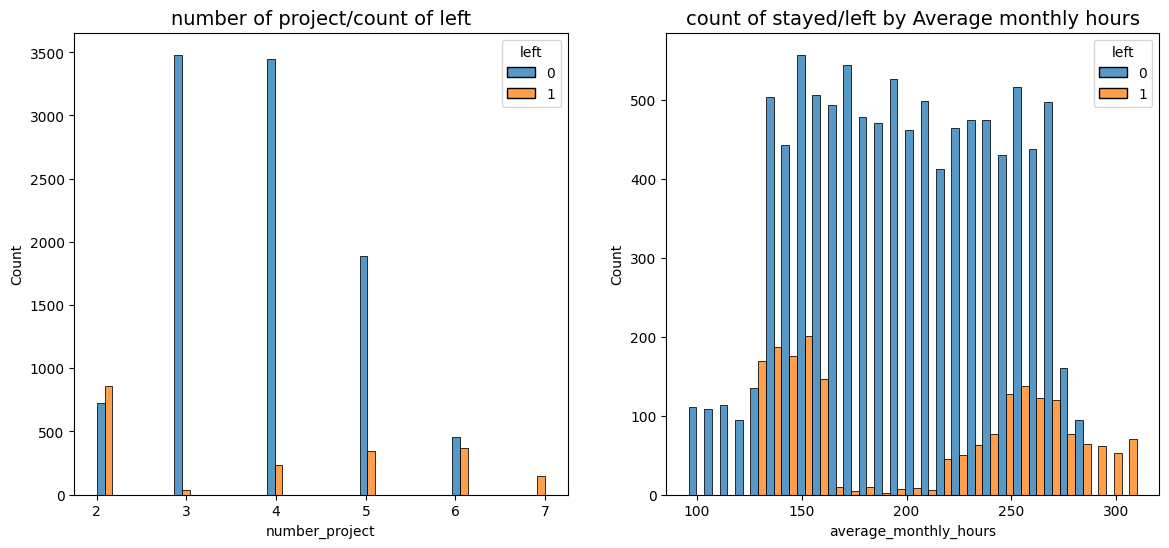

In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###
f, axs = plt.subplots(1, 2, figsize = (14,6))
sns.histplot(data = df1, x = 'number_project', hue = 'left', multiple = 'dodge', ax = axs[0])
axs[0].set_title("number of project/count of left", fontsize = 14)

sns.histplot(data = df1, x = 'average_monthly_hours', hue = 'left', multiple = 'dodge', ax = axs[1])
axs[1].set_title("count of stayed/left by Average monthly hours", fontsize = 14)
plt.show()

This graph clearly shows that their are Employees with increasing projects that are leaving the organization and their are a second group of Employees that have the least number of projects but still their leaving rate is one of the highest. Most underworked and overworked Employees are leaving the organization as there is no balance of work.

In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###
print(df1.groupby('number_project')['satisfaction_level'].mean())

number_project
2    0.499071
3    0.689418
4    0.694280
5    0.671155
6    0.314673
7    0.116690
Name: satisfaction_level, dtype: float64


In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###
df_number_p_2 = df1[df1['number_project'] == 2].head()
df_number_p_2.describe(include = 'all')

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
count,5.000000,5.000000,5.0,5.000000,5.0,5.0,5.0,5.0,5,5
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,5
mean,0.406000,0.524000,2.0,149.200000,3.0,0.0,1.0,0.0,NaN,NaN
std,0.032094,0.015166,0.0,10.305338,0.0,0.0,0.0,0.0,NaN,NaN
min,0.370000,0.500000,2.0,135.000000,3.0,0.0,1.0,0.0,NaN,NaN
25%,0.380000,0.520000,2.0,142.000000,3.0,0.0,1.0,0.0,NaN,NaN
50%,0.410000,0.530000,2.0,153.000000,3.0,0.0,1.0,0.0,NaN,NaN
75%,0.420000,0.530000,2.0,157.000000,3.0,0.0,1.0,0.0,NaN,NaN


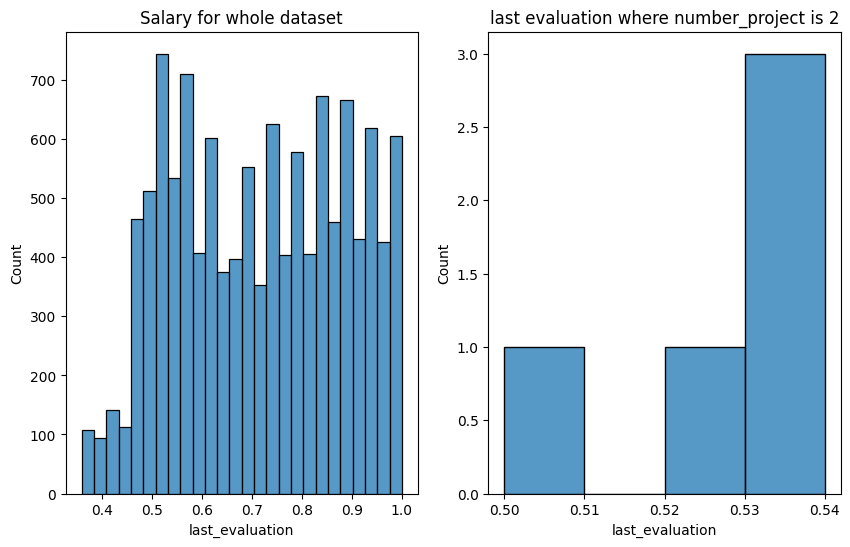

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
sns.histplot(data = df1, x = 'last_evaluation', ax = axs[0])
sns.histplot(data = df_number_p_2, x = 'last_evaluation', ax = axs[1])
axs[0].set_title("Salary for whole dataset")
axs[1].set_title("last evaluation where number_project is 2")
plt.show()

Exploring the Employees with the least number of projects, their evaluation score is moderate to low but this should not be the
case as with less number of projects they must be very efficient compared to the whole dataset. This shows that better management is required to drive employees towards efficiency.

/tmp/ipython-input-2762108436.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data = df1, x = 'tenure', y = 'satisfaction_level', hue = 'promotion_last_5years', ci = None)


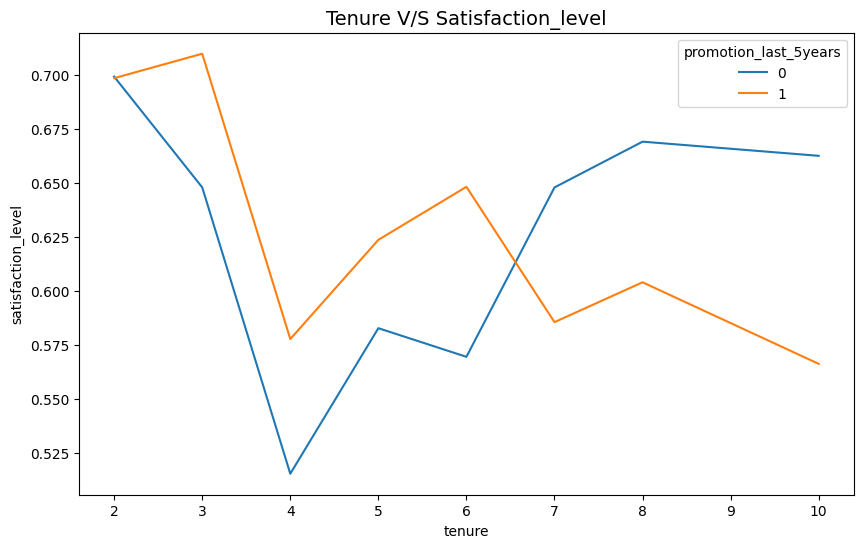

In [ ]:
plt.figure(figsize = (10,6))
sns.lineplot(data = df1, x = 'tenure', y = 'satisfaction_level', hue = 'promotion_last_5years', ci = None)
plt.title('Tenure V/S Satisfaction_level', fontsize = 14)
plt.show()

Exploring the tenure wise satisfaction, the Employees that have spent 4 years in the organization were having the least level of
satisfaction and to understand this further the promotion rate of these Employees were the lowest in the dataset. The Employees
having more then or equal to 6 year tenure are more satisfied with the organization compared to the other employees.

In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###
df1.groupby(df1['tenure'] == 4)['promotion_last_5years'].mean()

,promotion_last_5years
tenure,
False,0.018125
True,0.010973


/tmp/ipython-input-4036417500.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data = df1, x = 'department', y = 'tenure', ci = None, ax = axs[1])


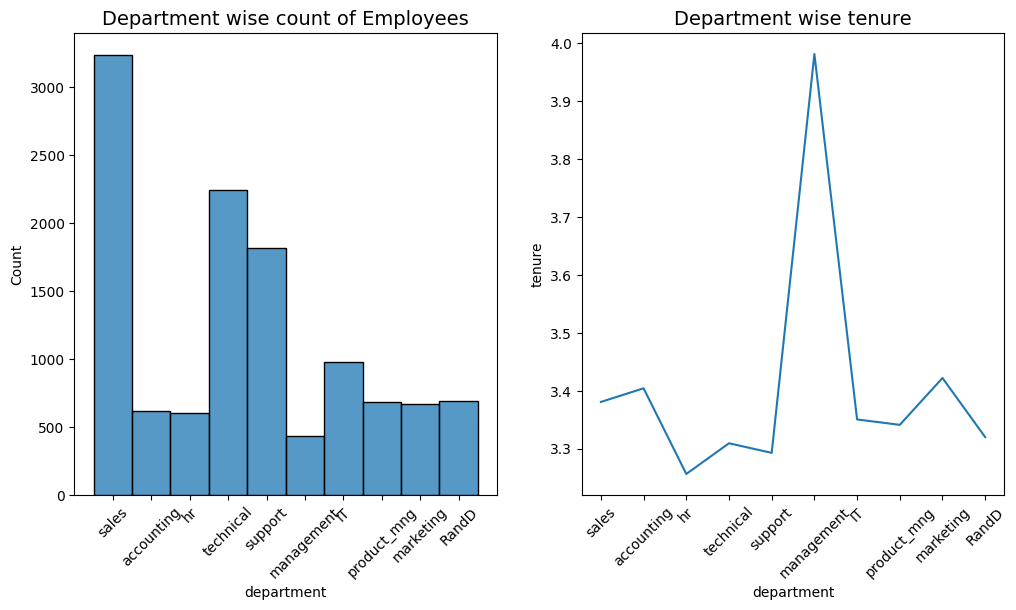

In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###
f, axs = plt.subplots(1,2,figsize = (12,6))
sns.histplot(data = df1, x = 'department', ax = axs[0])
axs[0].tick_params(axis='x', rotation=45)
axs[0].set_title("Department wise count of Employees", fontsize = 14)

sns.lineplot(data = df1, x = 'department', y = 'tenure', ci = None, ax = axs[1])
axs[1].tick_params(axis='x', rotation=45)
axs[1].set_title("Department wise tenure", fontsize = 14)
plt.show()

The management department having the smallest count is the most satisfied department with the organizatiton. It could be due to
the fact that there is very lenient observation of this department as rest of the facts uptill now are highly pointing towards
poor management.

/tmp/ipython-input-3328554229.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data = df1, x = 'department', y = 'satisfaction_level', ci = None)


Text(0.5, 1.0, 'Department wise Satisfaction')

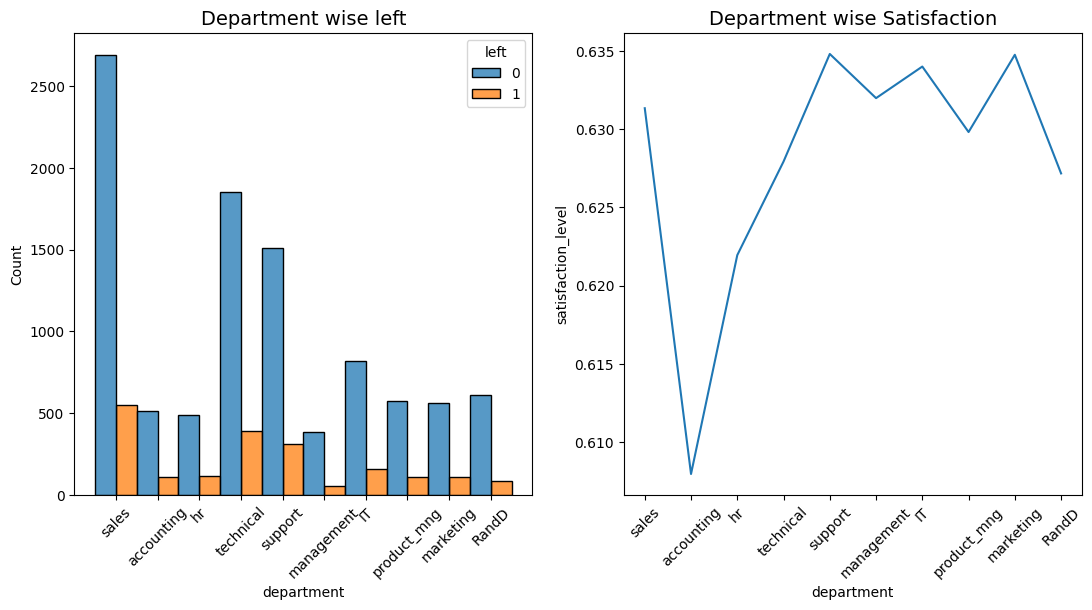

In [ ]:
f, axs = plt.subplots(1,2,figsize = (13,6))
sns.histplot(data = df1, x = 'department', hue = 'left', multiple = 'dodge', ax = axs[0])
axs[0].tick_params(axis = 'x', rotation = 45)
axs[0].set_title("Department wise left", fontsize = 14)

sns.lineplot(data = df1, x = 'department', y = 'satisfaction_level', ci = None)
axs[1].tick_params(axis = 'x', rotation = 45)
axs[1].set_title("Department wise Satisfaction", fontsize = 14)

Although the count of acounting and the hr department is less, still they are more towards leaving the organization. As per the
department wise satisfaction also these 2 departments mentioned above are the least satisfied with the organzation.

In [ ]:
df1.groupby('department')['left'].mean()

,left
department,
IT,0.161885
RandD,0.122478
accounting,0.175523
hr,0.188020
management,0.119266
marketing,0.166419
product_mng,0.160350
sales,0.169805
support,0.171334


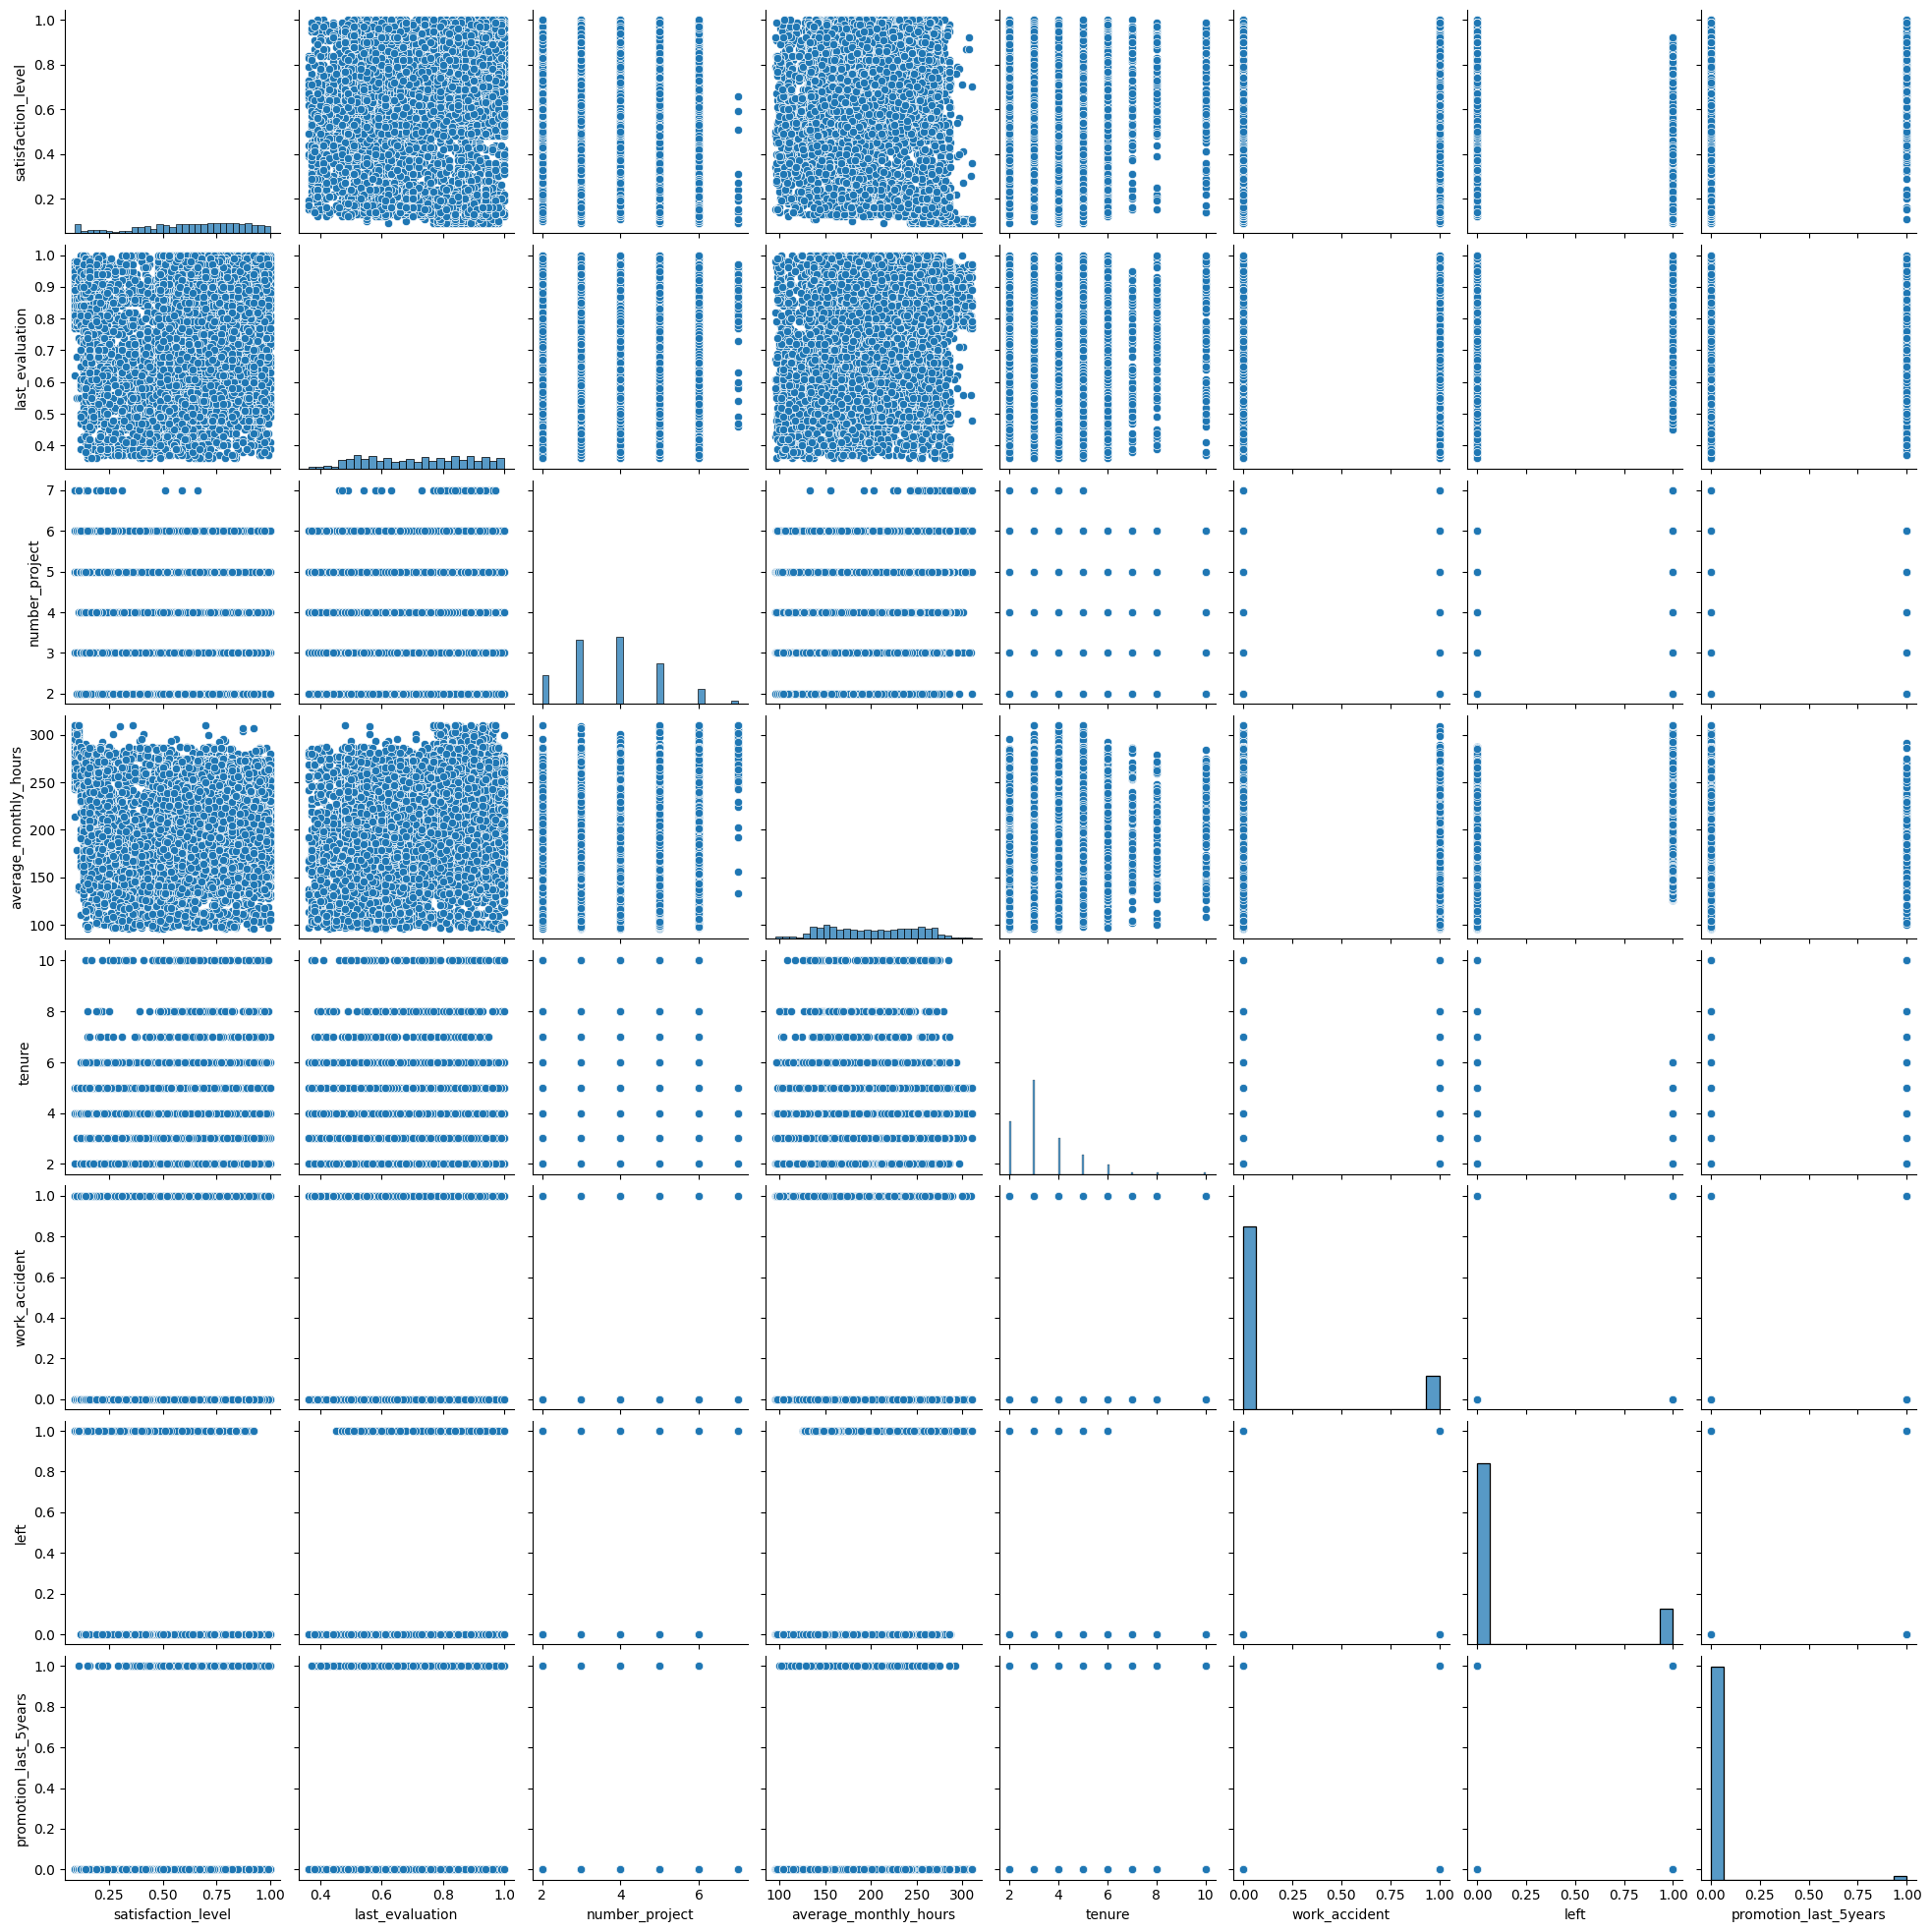

In [ ]:
sns.pairplot(data = df1)

their is no linearity in the given data

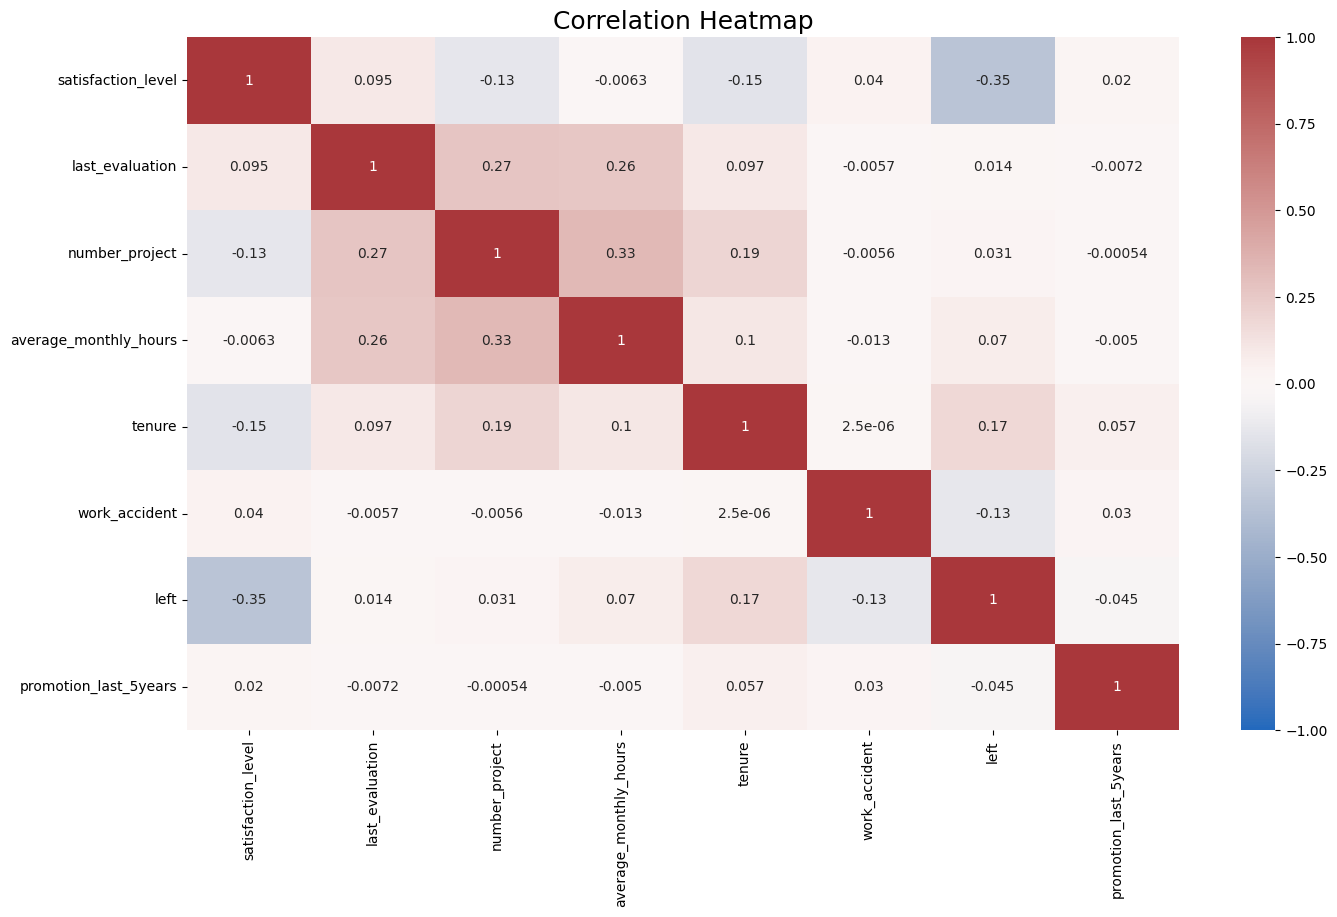

In [ ]:
plt.figure(figsize = (16, 9))
sns.heatmap(df1.corr(numeric_only=True), vmin=-1, vmax=1, annot = True, cmap=sns.color_palette("vlag", as_cmap=True))
plt.title("Correlation Heatmap", fontsize = 18)
plt.show()

there is a strong positive corelation btw last_evaluation, number_projects, average_monthly_hours and left is negatively correlated with the satisfaction_level

### Insights

1. Employees are overworked, and their is poor management in the organization
2. people working on only 2 projects are among the highest leavers and their salary are in the low category
3. Accounting department is the least satisfied
4. Althought the hr department entries are less but their left rate is the highest
5. There is no linearity in the data
6. the average tenure of the management department is the highest even though they are the smallest department
7. Employees are not getting promoted over the years, and probably burned out
8. there is a strong positive corelation btw last_evaluation, number_projects, average_monthly_hours and left is negatively correlated with the satisfaction_level

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



The class imbalance is on the higher side but not so severe that the dataset needs to be maipulated to lower this imbalance.

The columns that are choosen as independent variables are 'satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure', 'work_accident', 'promotion_last_5years', 'department', 'salary' because they meet the models assumptions and will only help to provide better predictions.

Yes, all the model assumptions are met.

With the overall accuracy of 81% , the model fits pretty well to data. But the low overall precision and recall on employees leaving the organizations might require some more techniques to increase the model's strength.

Applying tree based modeling approach might bear fruitful outcomes.

Libraries like sklearn, pandas, matplotlib.pyplot and seaborm are used.

Yes, the ethical concerns while working on this scenrio is that if the model predicts the employee left the organization but in fact did not leave(the case of false positive) might impact the employee's future in the company.

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

My goal is to predict whether an employee leaves the company, which is a categorical outcome variable. So this task involves classification. More specifically, this involves binary classification, since the outcome variable left can be either 1 (indicating employee left) or 0 (indicating employee didn't leave).

### Identify the types of models most appropriate for this task.

Since the variable I want to predict (whether an employee leaves the company) is categorical, I could either build a Logistic Regression model, or a Tree-based Machine Learning model.

So I could proceed with one of the two following approaches. Or, could implement both and determine how they compare.

### Modeling

Add as many cells as you need to conduct the modeling process.

In [ ]:
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
outlier = df1[(df1["tenure"] < lower_bound) | (df1["tenure"] > upper_bound)]
print("count of outliers in tenure: ", outlier.shape[0])
df1 = df1.drop(outlier.index)
df1.shape

count of outliers in tenure:  824


(11167, 10)

In [ ]:
df1.dtypes

,0
satisfaction_level,float64
last_evaluation,float64
number_project,int64
average_monthly_hours,int64
tenure,int64
work_accident,int64
left,int64
promotion_last_5years,int64
department,object
salary,object


In [ ]:
df1 = pd.get_dummies(data = df1, columns = ['department'], dtype = 'int')

In [ ]:
df1['salary'] = (
    df1['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11167 entries, 0 to 11999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      11167 non-null  float64
 1   last_evaluation         11167 non-null  float64
 2   number_project          11167 non-null  int64  
 3   average_monthly_hours   11167 non-null  int64  
 4   tenure                  11167 non-null  int64  
 5   work_accident           11167 non-null  int64  
 6   left                    11167 non-null  int64  
 7   promotion_last_5years   11167 non-null  int64  
 8   salary                  11167 non-null  int8   
 9   department_IT           11167 non-null  int64  
 10  department_RandD        11167 non-null  int64  
 11  department_accounting   11167 non-null  int64  
 12  department_hr           11167 non-null  int64  
 13  department_management   11167 non-null  int64  
 14  department_marketing    11167 non-null  int

In [ ]:
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
5,0.41,0.50,2,153,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


In [ ]:
X = df1.copy()
X = X.drop(columns = ['left'])
y = df1['left']

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = zip(X, vif)
vif_data = list(vif)
vif_df = pd.DataFrame(data = vif_data)
print(vif_data)

[('satisfaction_level', np.float64(1.0897101658425368)), ('last_evaluation', np.float64(1.1568322500223645)), ('number_project', np.float64(1.2601027057769747)), ('average_monthly_hours', np.float64(1.181017633664006)), ('tenure', np.float64(1.1300515298822393)), ('work_accident', np.float64(1.0036581068632484)), ('promotion_last_5years', np.float64(1.0139025195100522)), ('salary', np.float64(1.013785621444674)), ('department_IT', np.float64(4.800638892537043)), ('department_RandD', np.float64(3.708661675866467)), ('department_accounting', np.float64(3.4156596634474)), ('department_hr', np.float64(3.3095381216606197)), ('department_management', np.float64(2.5417779811311765)), ('department_marketing', np.float64(3.554762282530228)), ('department_product_mng', np.float64(3.618231003470046)), ('department_sales', np.float64(13.280595009544307)), ('department_support', np.float64(8.147735022591387)), ('department_technical', np.float64(9.783696619601209))]


In [ ]:
vif_df.head()

,0,1
0,satisfaction_level,1.089710
1,last_evaluation,1.156832
2,number_project,1.260103
3,average_monthly_hours,1.181018
4,tenure,1.130052


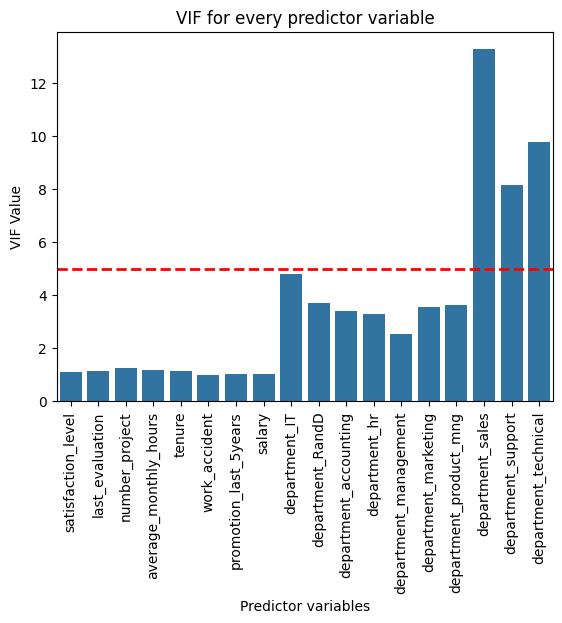

In [ ]:
sns.barplot(x = vif_df[0], y = vif_df[1])
plt.xticks(rotation = 90)
plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='Horizontal Line')
plt.title("VIF for every predictor variable")
plt.xlabel("Predictor variables")
plt.ylabel("VIF Value")
plt.show()

The VIF indicates that there is very low level of multicolinearity between the independent variables and we can move forward with building the model based on Logistic regression as all the necessary assumptions are met for the model to be successfull in predicting the desired outcome. The last 3 variables are having higher Vif then 5 but these will not drastically impact the model so we can move forward without removing them from the data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, stratify = y, random_state = 42)

In [ ]:
model = LogisticRegression(max_iter=600, random_state = 42)
clf = model.fit(X_train, y_train)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
print("precision_score: " , precision_score(y_test, y_pred))
print("recall_score: " , recall_score(y_test, y_pred))
print("accuracy_score: " , accuracy_score(y_test, y_pred))
print("f1_score: " , f1_score(y_test, y_pred))

precision_score:  0.44086021505376344
recall_score:  0.2611464968152866
accuracy_score:  0.8194842406876791
f1_score:  0.328


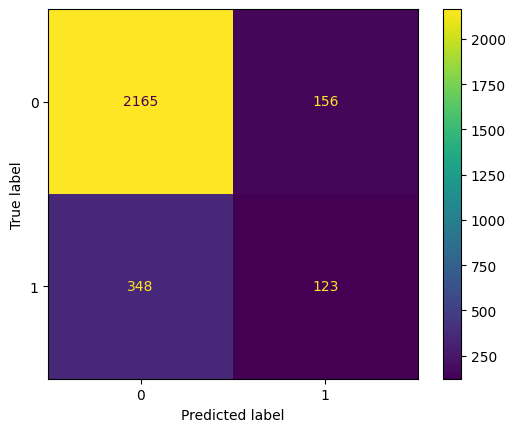

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels = clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = clf.classes_)
disp.plot(values_format='')

The upper-left quadrant displays the number of true negatives. The upper-right quadrant displays the number of false positives. The bottom-left quadrant displays the number of false negatives. The bottom-right quadrant displays the number of true positives.

True negatives: The number of people who did not leave that the model accurately predicted did not leave.

False positives: The number of people who did not leave the model inaccurately predicted as leaving.

False negatives: The number of people who left that the model inaccurately predicted did not leave

True positives: The number of people who left the model accurately predicted as leaving

In [ ]:
from sklearn.metrics import classification_report
target_names = ['Predicted would not leave', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))

                           precision    recall  f1-score   support

Predicted would not leave       0.86      0.93      0.90      2321
    Predicted would leave       0.44      0.26      0.33       471

                 accuracy                           0.82      2792
                macro avg       0.65      0.60      0.61      2792
             weighted avg       0.79      0.82      0.80      2792



The model made is having a strong average of predicting the Employees that would not leave the organization but if the focus is on the Employees that would leave than the desired outcome of the model may not be satifactory. This has happened mainly due to reason that the majority of the class was based on not leaving the organization and this class imbalance that was below the range of manipulating the dataset to reduce the class imbalance has made the model behave like this.

In [ ]:
stay_p = (df1['left'].value_counts()[0]/df1['left'].shape[0]) * 100
left_p = (df1['left'].value_counts()[1]/df1['left'].shape[0]) * 100
print("the left percentage: {} and the stay percentage: {}".format(round(left_p), round(stay_p, 2)))

the left percentage: 17 and the stay percentage: 83.15


# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



The model is strongly able to predict the employees not leaving the organisation but weak in predicting the employees leaving the organisation.

Based on the model the company could focus more on the factors contributing to the employees not leaving the company and if the company is more focused towards the factors contributing to the employees leaving the company, we can move towards balance the class in the dataset so that the model behaviour also changes to achieve desired outcomes.

We can also move towards tree based models to achieve more strong results.
We can use hyper parameter tuning to get the best averaged result in case of regression and the majority vote in case of classification problems like this one.

The employees certainly are overworked and there seems to be poor management in the company. No prompt promotions and large number of projects are driving the employees out of the company. We need to install better management frameworks to see the full picture clearly.
Making tree based models would definitely help a lot to the company.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

The model is having weighted precision and recall of 78% and 82% which makes this a strong model for predicting the employees that stayed in the company and the precision and recall for employees who left the company is 43% and 21% which is not so strong if the main focus is on the employees that are leaving the organizations. The class imbalance is of 83%/17% where 83% stayed and 17% left the company.

### Conclusion, Recommendations, Next Steps

Working on tree based modelling approach might bear fruitful results for the company.

# Tree based approach
## Decision Tree


In [ ]:
X = df1.copy()
X = X.drop(columns = ['left'])
y = df1['left']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, stratify = y, random_state = 42)

In [ ]:
tree_para = {'max_depth':[2,4,8, None],
        'min_samples_leaf':[2,3,4,7,10],
        'min_samples_split':[2,3,5]
            }
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [ ]:
%%time
decision_tree = DecisionTreeClassifier(random_state = 42)
dt_cv = GridSearchCV(
    decision_tree,
    tree_para,
    scoring = scoring,
    cv = 4,
    refit = 'roc_auc'
)
dt_cv.fit(X_train, y_train)

CPU times: user 6.46 s, sys: 12 ms, total: 6.48 s
Wall time: 6.85 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [2, 4, 8, None],
                         'min_samples_leaf': [2, 3, 4, 7, 10],
                         'min_samples_split': [2, 3, 5]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [ ]:
dt_cv.best_params_

{'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}

In [ ]:
print("The best validation score:",dt_cv.best_score_)

The best validation score: 0.9738991514831141


In [ ]:
def make_results(model_name:str, model_object, metric:str):
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'}

    cv_results = pd.DataFrame(model_object.cv_results_)
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]
    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    precision = best_estimator_results.mean_test_precision
    recall = best_estimator_results.mean_test_recall
    accuracy = best_estimator_results.mean_test_accuracy
    table = pd.DataFrame({'Model':[model_name],
                         'precision': [precision],
                          'recall': [recall],
                         'f1': [f1],
                         'accuracy': [accuracy],
                         'auc': [auc]})
    return table



In [ ]:
tree1_decision_results = make_results('decision_tree1_cv', dt_cv, 'auc')
tree1_decision_results

,Model,precision,recall,f1,accuracy,auc
0,decision_tree1_cv,0.959002,0.910002,0.933716,0.978269,0.973899


In [ ]:
tree_para_rf = {'max_depth':[2,4,None],
                'max_features':[1.0],
                'max_samples':[0.7,1.0],
               'min_samples_leaf': [2,4],
               'min_samples_split':[2,3,4],
               'n_estimators':[300, 500]}

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [ ]:
rf = RandomForestClassifier()
rf_cv = GridSearchCV(
    rf,
    tree_para_rf,
    scoring = scoring,
    cv = 4,
    refit = 'roc_auc'
)

In [ ]:
%%time
rf_cv.fit(X_train, y_train)

In [ ]:
path = 'employee-churn-prediction/models/'

In [ ]:
def write_pickle(path, model_object, save_as:str):
    '''
    In:
        path:         path of folder where you want to save the pickle
        model_object: a model you want to pickle
        save_as:      filename for how you want to save the model

    Out: A call to pickle the model in the folder indicated
    '''

    with open(path + save_as + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)

In [ ]:
def read_pickle(path, saved_model_name:str):
    '''
    In:
        path:             path to folder where you want to read from
        saved_model_name: filename of pickled model you want to read in

    Out:
        model: the pickled model
    '''
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)

    return model

In [ ]:
rf_cv_read = read_pickle('', 'random_forest_model_v1')


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GridSearchCV from version 1.4.2 when using version 1.6.1. This might lead to bre

In [ ]:
#this code cell will not work in collab env as it can not access the local storage
#rf_cv_read = read_pickle(path, 'RF1')

In [ ]:
#write_pickle(path, rf_cv, 'random_forest_model_v1')

In [ ]:
rf_cv_read.best_score_

np.float64(0.9813595384750136)

In [ ]:
rf_cv_read.best_params_

{'max_depth': 4,
 'max_features': 1.0,
 'max_samples': 1.0,
 'min_samples_leaf': 4,
 'min_samples_split': 3,
 'n_estimators': 500}

In [ ]:
rf_cv_read.best_estimator_

RandomForestClassifier(max_depth=4, max_features=1.0, max_samples=1.0,
                       min_samples_leaf=4, min_samples_split=3,
                       n_estimators=500)

In [ ]:
tree1_randomforest_results = make_results('random_forest1_cv', rf_cv_read, 'auc')
tree1_randomforest_results

,Model,precision,recall,f1,accuracy,auc
0,random_forest1_cv,0.953352,0.909294,0.930646,0.977194,0.98136


In [ ]:
#Comparing decision tree results with random forest
print(tree1_decision_results)
print(tree1_randomforest_results)

               Model  precision    recall        f1  accuracy       auc
0  decision_tree1_cv   0.959002  0.910002  0.933716  0.978269  0.973899
               Model  precision    recall        f1  accuracy      auc
0  random_forest1_cv   0.953352  0.909294  0.930646  0.977194  0.98136


The random forest by slight higher values outperforms the decision tree. Next lets use the random forest to predict the test data

In [ ]:
def make_scores(model_name:str, model, X_test_data, y_test_data):
    preds = model.best_estimator_.predict(X_test_data)

    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({
        'model': [model_name],
        'auc': [auc],
        'precision': [precision],
        'recall': [recall],
        'f1': [f1]

    })
    return table

In [ ]:
rf1_test_result = make_scores('random_forest1_test', rf_cv_read, X_test, y_test)
rf1_test_result

## Addressing Overfitting
- The strong results of the model might raise the questions of Data leakage. Data leakage is when there is certain column in the training set that is prediciting the target variable and the model starts ignoring other revelant variables in forming an outcome.
- Let us try again by droping the satisfaction_level column and applying feature engineering on the overworked column to create a new binary value column named overworked.
- This new feature might address the problem of the employees working lesser as they have already planned to leave the company or are to be fired by the management, so they are given less work. This results in model learning a correlation that might not be true in real world scenerios and produce irrelevant results.

In [ ]:
df2 = df1.copy()
df2 = df2.drop(columns = ['satisfaction_level'])
df2.head()

,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
2,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
5,0.50,2,153,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


In [ ]:
print(df1['average_monthly_hours'].min())
print(df1['average_monthly_hours'].max())

96
310


166.67 is approximately the average number of monthly hours for someone who works 50 weeks per year, 5 days per week, 8 hours per day.

In [ ]:
df2['overworked'] = df2['average_monthly_hours']

In [ ]:
df2['overworked'] = (df2['overworked'] > 175).astype(int)
df2['overworked'].head()

,overworked
0,0
2,1
3,1
4,0
5,0


In [ ]:
df2 = df2.drop(columns = ['average_monthly_hours'])
df2.head()

,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked
0,0.53,2,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
2,0.88,7,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1
3,0.87,5,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1
4,0.52,2,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
5,0.50,2,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0


In [ ]:
X = df2.copy()
X = X.drop(columns = ['left'])
y = df2['left']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, stratify = y, random_state = 0)

In [ ]:
X.head()

,last_evaluation,number_project,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked
0,0.53,2,3,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,0.88,7,4,0,0,1,0,0,0,0,0,0,0,1,0,0,1
3,0.87,5,5,0,0,0,0,0,0,0,0,0,0,1,0,0,1
4,0.52,2,3,0,0,0,0,0,0,0,0,0,0,1,0,0,0
5,0.50,2,3,0,0,0,0,0,0,0,0,0,0,1,0,0,0


### Decision Tree Round 2

In [ ]:
decision_tree = DecisionTreeClassifier(random_state = 0)
tree_para = {'max_depth':[2,4,8, None],
        'min_samples_leaf':[2,3,4,7,10],
        'min_samples_split':[2,3,5]
            }
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [ ]:
dt_cv2 = GridSearchCV(decision_tree,
                     tree_para,
                     scoring = scoring,
                     cv = 4,
                     refit = 'roc_auc')

In [ ]:
%%time
dt_cv2.fit(X_train, y_train)

CPU times: user 5.25 s, sys: 2.09 ms, total: 5.25 s
Wall time: 5.3 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [2, 4, 8, None],
                         'min_samples_leaf': [2, 3, 4, 7, 10],
                         'min_samples_split': [2, 3, 5]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [ ]:
dt_cv2.best_params_

{'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2}

In [ ]:
dt_cv2.best_score_

np.float64(0.9619769048027507)

In [ ]:
tree2_decision_results = make_results('decision_tree2_cv', dt_cv2, 'auc')
tree2_decision_results

,Model,precision,recall,f1,accuracy,auc
0,decision_tree2_cv,0.850637,0.905047,0.876801,0.957134,0.961977


Some of the other scores fell. That's to be expected given fewer features were taken into account in this round of the model. Still, the scores are very good.

### Random Forest Round 2

In [ ]:
rf = RandomForestClassifier(random_state = 0)
tree_para_rf = {'max_depth':[2,4,None],
                'max_features':[1.0],
                'max_samples':[0.7,1.0],
               'min_samples_leaf': [2,4],
               'min_samples_split':[2,3,4],
               'n_estimators':[300, 500]}

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [ ]:
rf_cv2 = GridSearchCV(rf,
                     tree_para_rf,
                     scoring = scoring,
                     cv = 4,
                     refit = 'roc_auc')

In [ ]:
%%time
rf_cv2.fit(X_train, y_train)

CPU times: user 9min 32s, sys: 827 ms, total: 9min 33s
Wall time: 9min 36s


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [2, 4, None], 'max_features': [1.0],
                         'max_samples': [0.7, 1.0], 'min_samples_leaf': [2, 4],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [300, 500]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [ ]:
#write_pickle(path, rf_cv2, 'random_forest_model_v2')

In [ ]:
#this cell won't work as collab env won't be able to access the local storage
#rf_cv2_read = read_pickle(path, 'RF2')

In [ ]:
rf_cv2_read = read_pickle('', 'random_forest_model_v2')

In [ ]:
rf_cv2_read.best_score_

np.float64(0.9673102618098257)

In [ ]:
rf_cv2_read.best_params_

{'max_depth': 4,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 500}

In [ ]:
tree2_randomforest_results = make_results('random_forest2_cv', rf_cv2_read, 'auc')
tree2_randomforest_results

,Model,precision,recall,f1,accuracy,auc
0,random_forest2_cv,0.857471,0.901504,0.878784,0.95809,0.96731


In [ ]:
print(tree2_decision_results)
print(tree2_randomforest_results)

               Model  precision    recall        f1  accuracy       auc
0  decision_tree2_cv   0.850637  0.905047  0.876801  0.957134  0.961977
               Model  precision    recall        f1  accuracy      auc
0  random_forest2_cv   0.857471  0.901504  0.878784   0.95809  0.96731


The scores for both the models have dropped slightly but still the random forest model performs better than the decision tree model.

In [ ]:
rf2_test_result = make_scores('random_forest2_test', rf_cv2_read, X_test, y_test)
rf2_test_result

,model,auc,precision,recall,f1
0,random_forest2_test,0.942226,0.850394,0.917197,0.882533


This is the final stable well-performing final model

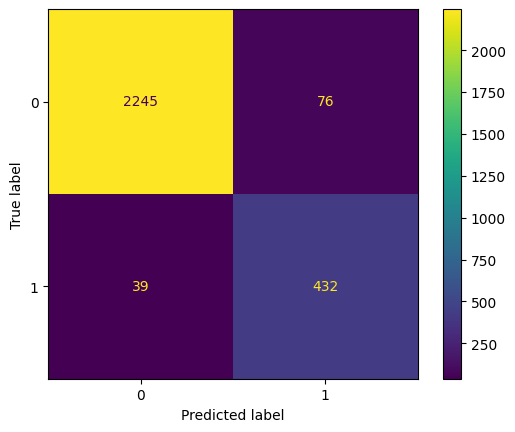

In [ ]:
#plotting the confusion matrix
preds = rf_cv2.best_estimator_.predict(X_test)

cm = confusion_matrix(y_test, preds, labels = rf_cv2.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = rf_cv2.classes_)

disp.plot(values_format = '')

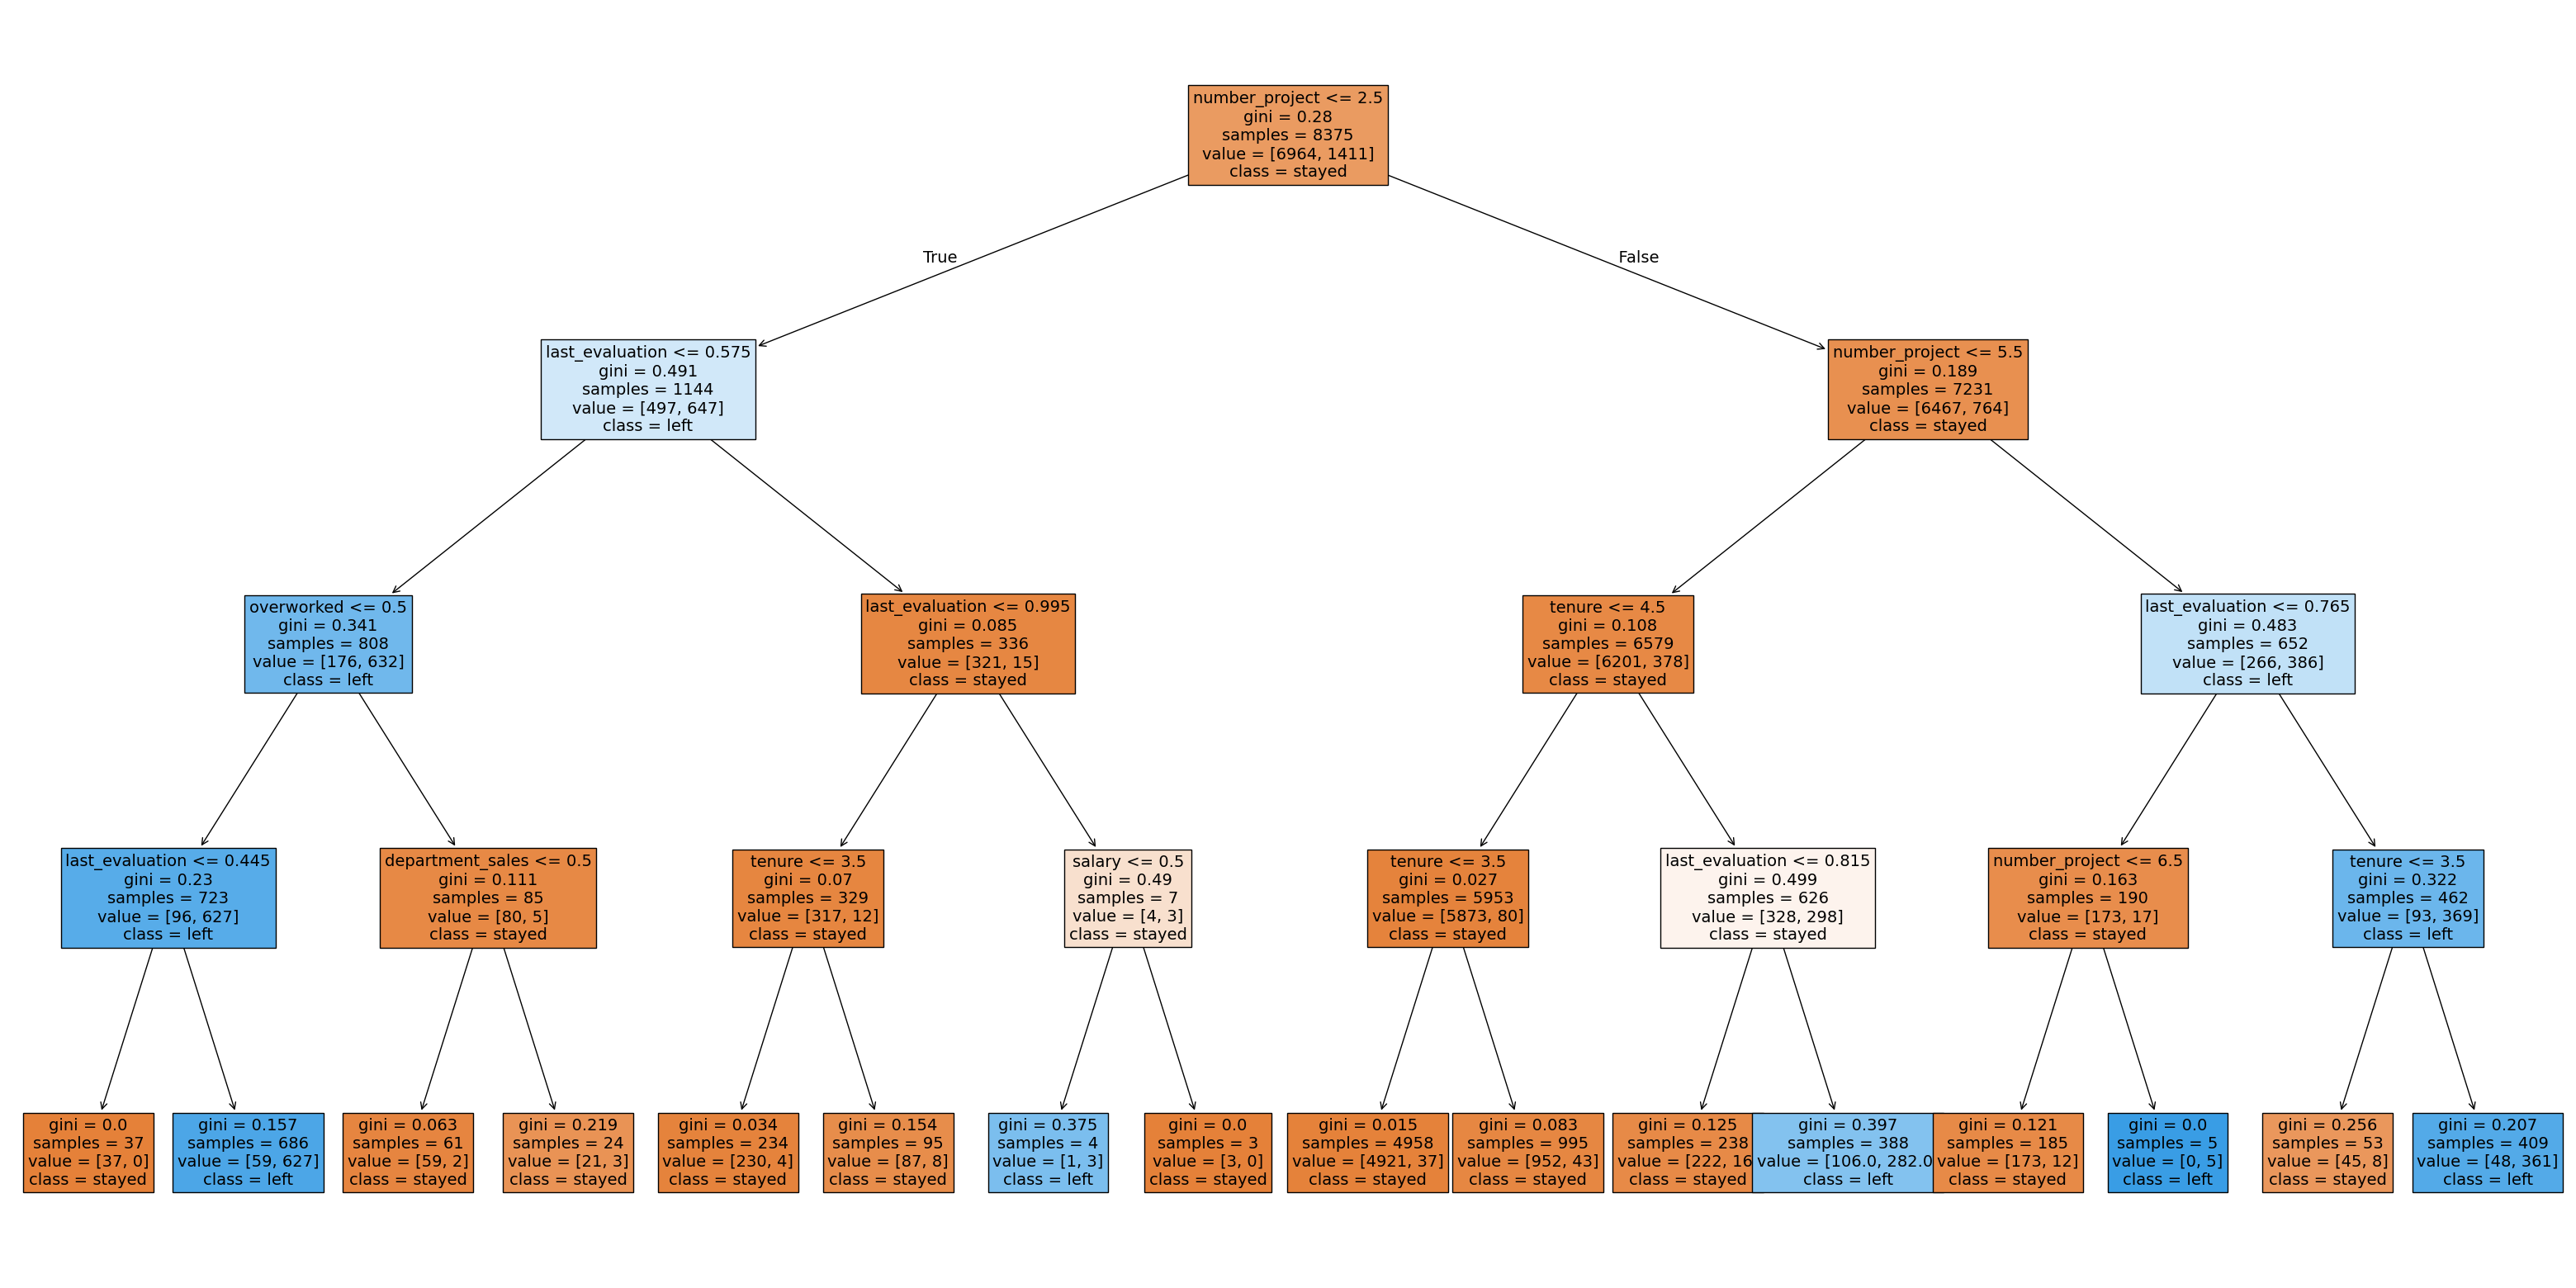

In [ ]:
#Plotting the Decision tree graph
plt.figure(figsize = (40,20))
plot_tree(dt_cv2.best_estimator_, max_depth = 4, fontsize = 14, feature_names = X.columns, class_names = {0: 'stayed', 1: 'left'}, filled = True )
plt.show()

In [ ]:
dt_feature_importance = pd.DataFrame(data = dt_cv2.best_estimator_.feature_importances_,
                                    columns = ['gini_impurity'],
                                    index = X.columns)
dt_feature_importance = dt_feature_importance.sort_values(by = 'gini_impurity', ascending = False)

dt_feature_importance[dt_feature_importance['gini_impurity'] > 0]

,gini_impurity
number_project,0.438579
last_evaluation,0.333916
tenure,0.169270
overworked,0.056963
salary,0.001105
department_sales,0.000168


#### Decision tree Feature importance

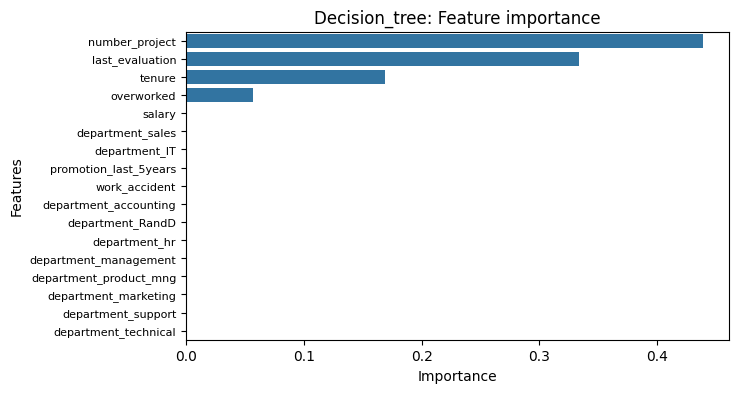

In [ ]:
plt.figure(figsize = (7, 4))
sns.barplot(data = dt_feature_importance, x = 'gini_impurity', y = dt_feature_importance.index, orient = 'h')
plt.xlabel("Importance")
plt.tick_params(axis='y', labelsize=8)
plt.ylabel("Features")
plt.title("Decision_tree: Feature importance")
plt.show()

According to the above graph the most important feature for predicting whether an employee would leave the organization are:
- number_project
- last_evaluation
- tenure
- Overworked                                                

#### Random Forest Feature importance

In [ ]:
rf_cv2_read.best_estimator_.feature_importances_

rf_feature_importance = pd.DataFrame(data = rf_cv2_read.best_estimator_.feature_importances_,
                                    columns = ['importance'],
                                    index = X.columns)

rf_feature_importance = rf_feature_importance.sort_values(by = 'importance', ascending  = False)

rf_feature_importance


,importance
number_project,0.420890
last_evaluation,0.335659
tenure,0.185296
overworked,0.056802
salary,0.000408
department_sales,0.000238
department_IT,0.000142
department_support,0.000126
work_accident,0.000101
department_technical,0.000091


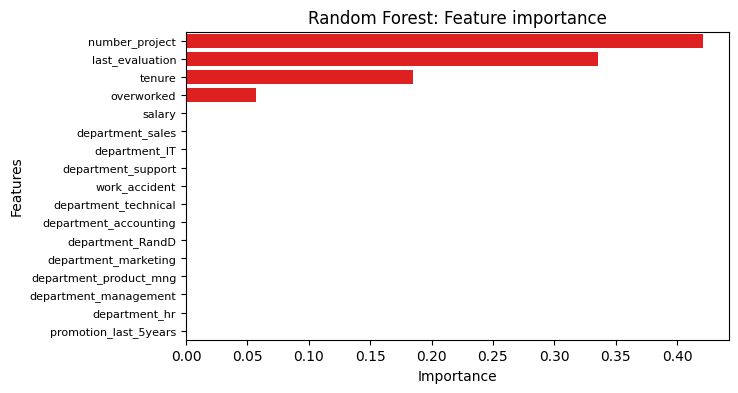

In [ ]:
plt.figure(figsize = (7, 4))
colors = ['red']
sns.set_palette(colors)
sns.barplot(data = rf_feature_importance, x = 'importance', y = rf_feature_importance.index, orient = 'h')
plt.xlabel("Importance")
plt.tick_params(axis='y', labelsize=8)
plt.ylabel("Features")
plt.title("Random Forest: Feature importance")
plt.show()

The most important feature in predicting the target variable are number_projects, last_evaluation, tenure, overworked. They are the same as the decision tree model.

# Conclusion

Logistic Regression model:
- The model performs well for predicting the employees that stayed in the company.
- With the precision of 79%, recall of 82%, and an accuracy of 80%(all weighted avg)                 

Random Forest Model:
- The model scores slightly better than the decision tree model, making this the final most sutable model for answering the questions of the organization
- with an AUC score of 94%, precision of 85%, recall of 91%, F1-score of 88% on the final test data.

# Insights
- The most important features for predicting if the employees would leave are number_projects, last_evaluation, tenure, overworked in the same order as mentioned.
- The number of projects should be reduced.
- The employees having to work overtime (more then 200 hours per month) should be rewarded in a proper balanced manner throughtout the different departments.
- Promotion should be given to Employees working more than 4 years in the organization.
- Meetings about the work culture should be held for the employees to better understand the functioning of the organization.
- High evaluation scores should not be revserved for employees working more than 200 hours per month.